## Analysing black-box tuning results

In [1]:
import os
import json
import traceback
import warnings

import numpy as np 
import pandas as pd # 0.25.1

import seaborn as sns # 0.9.0
from matplotlib.patches import Rectangle, Patch
import matplotlib.pyplot as plt
import matplotlib

from glob import glob
from tqdm import tqdm

from sklearn.metrics import auc

from collections import Counter
from itertools import cycle

import textalloc as ta  # for smart text placement in plots

np.random.seed(42)

# Matplotlib and Seaborn style setup
matplotlib.rc("pdf", fonttype=42)
matplotlib.rc("ps", fonttype=42)
sns.set(style="ticks", palette="magma")
sns.set_context("paper", font_scale=1.25, rc={"lines.linewidth": 1.1})

# Directories
rdir = '../../results/black-box-tuning/'
figdir = '../figs/black-box-tuning/'
datadir = '../../datasets/blackbox/'

def save(name='tmp', h=None, figdir=None, tight_layout=True):
    """Save current matplotlib figure to PDF and PNG in the specified directory."""

    name = name.strip().replace(' ', '-').replace('%', 'pct')
    h = h or plt.gcf()

    if tight_layout:
        h.tight_layout()

    if figdir:
        out_pdf = os.path.join(figdir, f'{name}.pdf')
        out_png = os.path.join(figdir, f'{name}.png')

        os.makedirs(figdir, exist_ok=True)
        print(f'Saving {out_pdf}')
        plt.savefig(out_pdf, bbox_inches='tight')
        plt.savefig(out_png, bbox_inches='tight')
    else:
        print('Plot was not saved because no figdir was specified')
        plt.show()

# read data from feather

In [2]:
df = pd.read_feather(rdir + 'results.feather')  # raw results for each run and dataset

display(df.sample())
print(df.random_state.unique())

print('mean trial count:')
print(
    df.groupby('algorithm')['dataset'].count().sort_values()
    / df.dataset.nunique()
)

# Remove specific Genetic Engine variants
df = df[~df['algorithm'].isin(['Genetic Engine rs', 'Genetic Engine hc', 'Genetic Engine 1p1'])]

# Simplify algorithm name
df = df.replace({'Genetic Engine': 'G. Engine'})

# Prepare plotting DataFrame
df_plot = df.copy().fillna(-1)
df_plot.loc[df_plot.r2_test < 0, 'r2_test'] = -1  # clip negative r2_test

# including-excluding specific results (examples) -----------------------------------------

# Exclude AFP_FE results
# df_plot = df_plot[~df_plot['algorithm'].isin(['AFP_FE'])]

# Exclude specific algorithms
# df_plot = df_plot[~df_plot['algorithm'].isin([
#     'E2E', 'TPSR', 'NeSymRes'
# ])]

# Filter by random state to keep only first 10 runs
# df_plot = df_plot[~df_plot['random_state'].isin([
#     '14423', '15795', '16850', '21962', '23654', '28020', '29910', '4426', '5390', '860'
# ])]


,dataset,algorithm,random_state,training time (s),symbolic_model,mse_test,mae_test,r2_test,model_size,params_str,training time (hr),symbolic_alg,pre_trained,gp_alg,r2_zero_test,friedman_dataset
5573,579_fri_c0_250_5,Genetic Engine,8322,3600.016628,((x0 + x3) * (1.0 / 2.0)),0.509724,0.614359,0.51744,7,"{'max_time': 3600, 'seed': 0}",1.000005,True,False,False,0.51744,True


[11284 11363 11964 14423 15795 16023 16850  1685 21575 21962 22118 23333
 23654  2433 26967 27495 28020 29802 29910 30187 32052 32157  4426  5051
  5311  5390  6265   769  8322   860]
mean trial count:
algorithm
PS-Tree           10.500000
AFP_FE            15.416667
FEAT              21.166667
Brush             23.666667
E2E               24.750000
PYSR              27.500000
Operon            27.750000
NeSymRes          29.833333
Rils-Rols         29.833333
Bingo             30.000000
FFX               30.000000
EQL               30.000000
EPLEX             30.000000
AFP_EHC           30.000000
BSR               30.000000
AFP               30.000000
ITEA              30.000000
Genetic Engine    30.000000
GPZGD             30.000000
GP-GOMEA          30.000000
QLattice          30.000000
TIR               30.000000
TPSR              30.000000
gplearn           30.000000
Name: dataset, dtype: float64


# Total runtime

In [3]:
intervals = (
    ('years', 31534272),  # 60 * 60 * 24 * 7 * 52.14
    ('weeks', 604800),    # 60 * 60 * 24 * 7
    ('days', 86400),      # 60 * 60 * 24
    ('hours', 3600),      # 60 * 60
    ('minutes', 60),      
    ('seconds', 1),
)

def display_time(seconds, granularity=7):
    result = []

    for name, count in intervals:
        value = seconds // count
        if value:
            seconds -= value * count
            if value == 1:
                name = name.rstrip('s')
            result.append("{} {}".format(int(value), name))
    return ', '.join(result[:granularity])

# Just for calculating execution time
print('Total training time', display_time(df['training time (s)'].sum()))

Total training time 11 weeks, 6 hours, 52 minutes, 55 seconds


# Performance profile plots

Saving ../figs/black-box-tuning/r2_perf_full.pdf


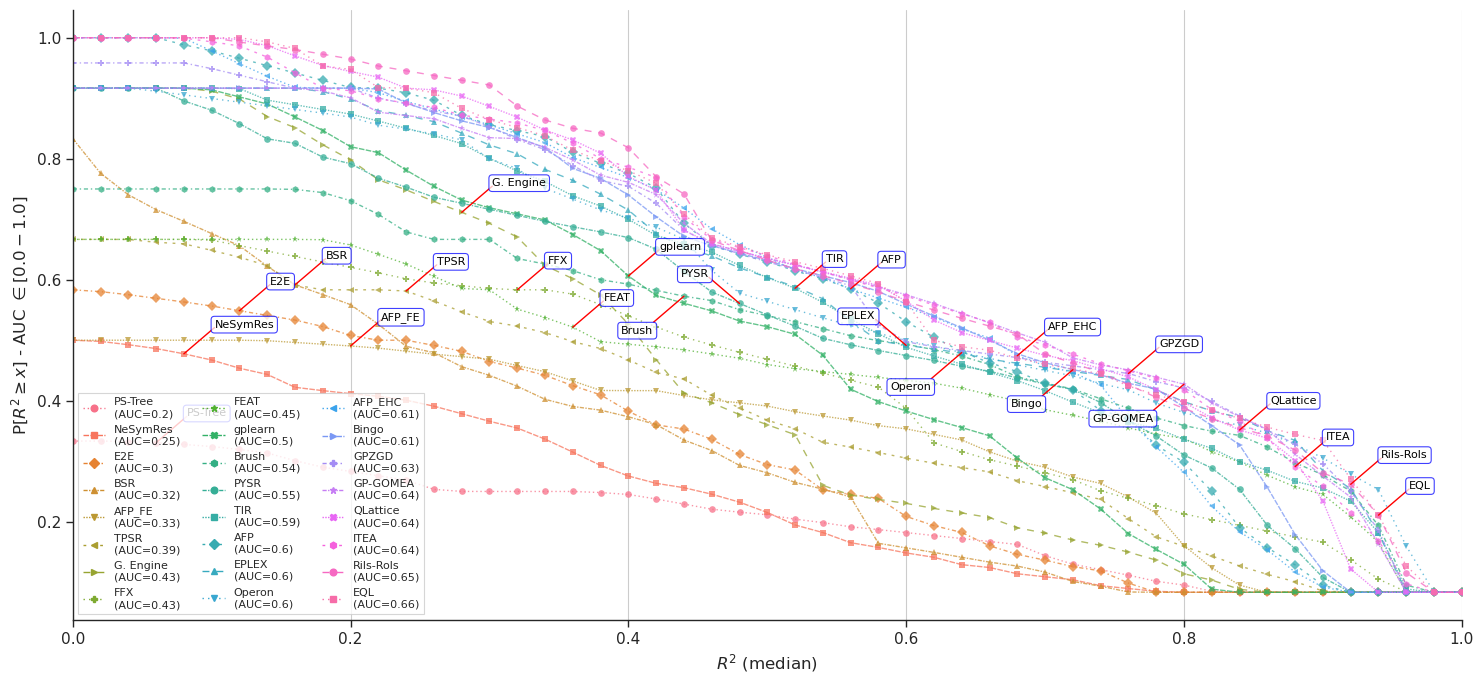

In [4]:
def perfprof_plot(
    df,
    perf_measure,
    *,
    interval=(0.0, 1.0),
    errorbar=None,
    estimator=np.median,
    annot=True,
    ax=None,
    legend=True,
    legend_loc='lower left',
    xlabel=True,
    ylabel=True
):
    """
    Plot performance profiles across algorithms using cumulative distribution of a performance measure.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame containing columns: ['algorithm', 'dataset', 'random_state', perf_measure].
    perf_measure : str
        The column name of the performance metric to plot (e.g., 'r2_test').
    interval : tuple of float, optional
        Defines the interval of AUC values to include in the main plot (others are grayed out).
    errorbar : str or None, optional
        Error bar strategy passed to seaborn.lineplot (e.g., 'sd', 'se', or None).
    estimator : callable, optional
        Function used to aggregate AUCs across random seeds (default: np.median).
    annot : bool, optional
        If True, adds algorithm name annotations on the plot.
    ax : matplotlib.axes.Axes, optional
        Axis object to draw on. If None, creates a new figure.
    legend : bool, optional
        Whether to include a legend.
    legend_loc : str, optional
        Legend location (default: 'lower left').
    xlabel : bool, optional
        Whether to show the x-axis label.
    ylabel : bool, optional
        Whether to show the y-axis label.

    Returns
    -------
    matplotlib.axes.Axes
        The axis containing the performance profile plot.
    """

    dashes = [(1, 2), (4, 1), (3, 2, 1, 2), (3, 1, 1, 1), (1, 1), (2, 4), (5, 5), (1, 3)]
    dashcycler = cycle(dashes)
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*', 'X', 'h']
    markercycler = cycle(markers)

    base_fpr = np.linspace(0, 1, 51)

    suffix = "" if interval == (0.0, 1.1) else \
             f" - AUC $\\in {np.round(interval, 2).tolist()}$".replace(", ", "-").replace("(", "[")

    if ax is None:
        plt.figure(figsize=(15, 7))
        ax = plt.gca()

    df = df[['algorithm', 'dataset', 'random_state', perf_measure]]
    n_problems = df['dataset'].nunique()
    plot_data = []

    # Compute AUCs per algorithm across random states
    for name, view in df.groupby('algorithm'):
        view = view[view[perf_measure] >= 0].sort_values(by=perf_measure)
        frames, AUCs = [], []

        for rs, view2 in view.groupby('random_state'):
            n_gt0 = view2.shape[0]
            perf_x, perf_y = [0], [n_gt0 / n_problems]

            # Build performance curve by counting decreasing probabilities
            for k, perf in Counter(view2[perf_measure].values).items():
                if k == 0:
                    n_gt0 -= perf
                    continue
                perf_x.append(k)
                perf_y.append(n_gt0 / n_problems)
                n_gt0 -= perf

            # Interpolate over base_fpr grid and compute AUC
            perf_y = np.interp(base_fpr, perf_x, perf_y)
            AUC_val = auc(base_fpr, perf_y)
            AUCs.append(AUC_val)
            frames.extend({
                'perf_x': x,
                'perf_y': y,
                'random_state': rs,
                'algorithm': name,
                'AUC': AUC_val
            } for x, y in zip(base_fpr, perf_y))

        df_frames = pd.DataFrame.from_records(frames)
        plot_data.append((estimator(AUCs), name, df_frames))

    # Sort by median AUC
    plot_data.sort(key=lambda x: x[0])
    cmap = np.array(sns.color_palette("Spectral", n_colors=len(plot_data)))
    marker_dict, dashes_dict = {}, {}
    algs_in = pd.DataFrame()
    c_idxs = []

    # Plot algorithms inside/outside the AUC interval
    for i, (AUC_val, name, df_frames) in enumerate(plot_data):
        pretty_name = f'{name}\n(AUC={np.round(AUC_val, 2)})'
        df_frames['algorithm'] = pretty_name

        if interval[0] <= np.round(AUC_val, 2) < interval[1]:
            marker_dict[pretty_name] = next(markercycler)
            dashes_dict[pretty_name] = next(dashcycler)
            algs_in = pd.concat([algs_in, df_frames])
            c_idxs.append(i)
        elif np.isfinite(AUC_val):
            sns.lineplot(
                data=df_frames, x='perf_x', y='perf_y', linewidth=1, ls=":", ax=ax,
                alpha=0.2, color='gray', errorbar=None, label=None, estimator=estimator
            )

    # Plot colored curves for algorithms in interval
    if not algs_in.empty:
        ax = sns.lineplot(
            data=algs_in, x='perf_x', y='perf_y', linewidth=1, ax=ax,
            color=cmap[c_idxs], errorbar=errorbar, estimator=estimator,
            hue='algorithm', style='algorithm', alpha=0.75,
            markeredgewidth=0, markers=marker_dict, dashes=dashes_dict
        )

        if annot:
            # Compute representative positions for text annotations
            grouped_lines = algs_in.groupby(['algorithm', 'perf_x']).agg(estimator)\
                                   .reset_index().sort_values('AUC')

            closest_fpr_point = lambda p: min(base_fpr, key=lambda x: abs(x - p))
            x = [closest_fpr_point(xpos) for xpos in np.linspace(0.05, 0.95, len(grouped_lines['algorithm'].unique()))]
            y = [grouped_lines[grouped_lines['perf_x'] == xpos]['perf_y'].max() for xpos in x]
            y_line = [
                grouped_lines[
                    (grouped_lines['perf_x'] == closest_fpr_point(xpos)) &
                    (grouped_lines['algorithm'] == alg)
                ]['perf_y'].max()
                for xpos, alg in zip(x, grouped_lines['algorithm'].unique())
            ]

            ta.allocate(
                ax, x, y_line,
                grouped_lines['algorithm'].str.replace("\\n\\(.*\\)", "", regex=True).unique(),
                min_distance=0.02, avoid_label_lines_overlap=True, avoid_crossing_label_lines=True,
                x_scatter=x, y_scatter=y, textsize=8,
                **{"bbox": dict(facecolor='w', edgecolor='b', boxstyle='round', alpha=0.75)}
            )

    # Axis formatting
    ax.set_xlim((0, 1.0))
    label = perf_measure.replace('_', ' ').replace(' test', '').replace('r2', 'R^2').title()

    if xlabel:
        if df['random_state'].nunique() == 1:
            ax.set_xlabel(f"${label}$")
        else:
            ax.set_xlabel(f"${label}$ ({estimator.__name__})")
    else:
        ax.set_xlabel("")

    if ylabel:
        ax.set_ylabel(f"P[${label} \\geq x$]{suffix}")
    else:
        ax.set_ylabel("")

    if legend:
        leg = ax.legend(loc=legend_loc, ncol=3, fancybox=False, shadow=False, prop={'size': 8})
        for legobj in leg.legendHandles:
            legobj.set_linewidth(1.0)
    else:
        ax.get_legend().remove()

    ax.grid(axis='x')
    sns.despine()

    return ax

# Examples on how to generate different perfplots ------------------------------
# perfprof_plot(df_plot, "r2_test", errorbar=None, estimator=np.min)
# perfprof_plot(df_plot, "r2_test", errorbar=None, estimator=np.max)

perfprof_plot(df_plot, "r2_test", errorbar=None, estimator=np.median)
save(name='r2_perf_full', figdir=figdir)

Saving ../figs/black-box-tuning/r2_perf_intervals.pdf


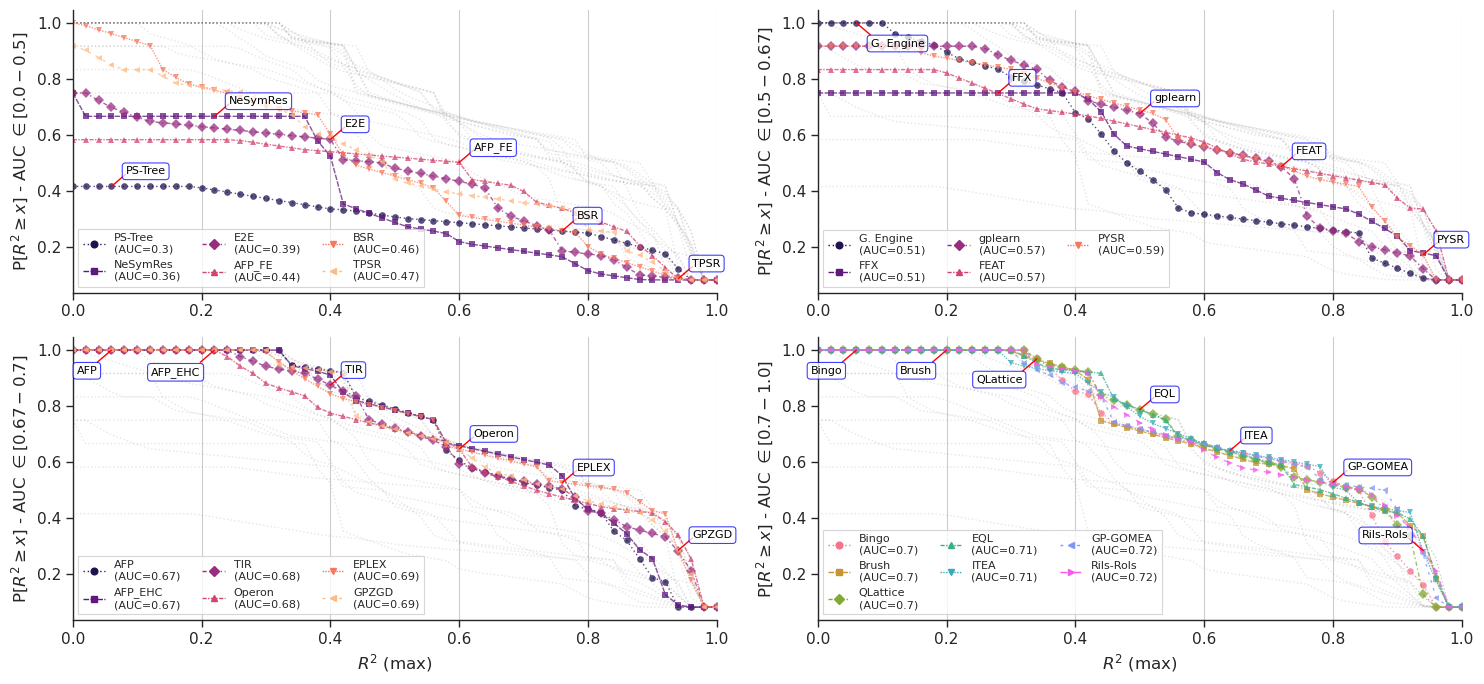

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(15, 7))

# Selecting based on overall performance
for i, (ax, interval) in enumerate(zip(fig.axes, [(0, 0.5), (0.5, 0.67), (0.67, 0.7), (0.7, 1.0)])):
    perfprof_plot(df_plot, "r2_test", interval=interval, errorbar=None, estimator=np.max, ax=ax, legend=True, xlabel=i>1)
    
save(name=f'r2_perf_intervals'.replace(", ", "-"), figdir=figdir)

# Summarizing performance profiles as tables with AUC

Saving ../figs/black-box-tuning/r2_AUC_tuning.pdf


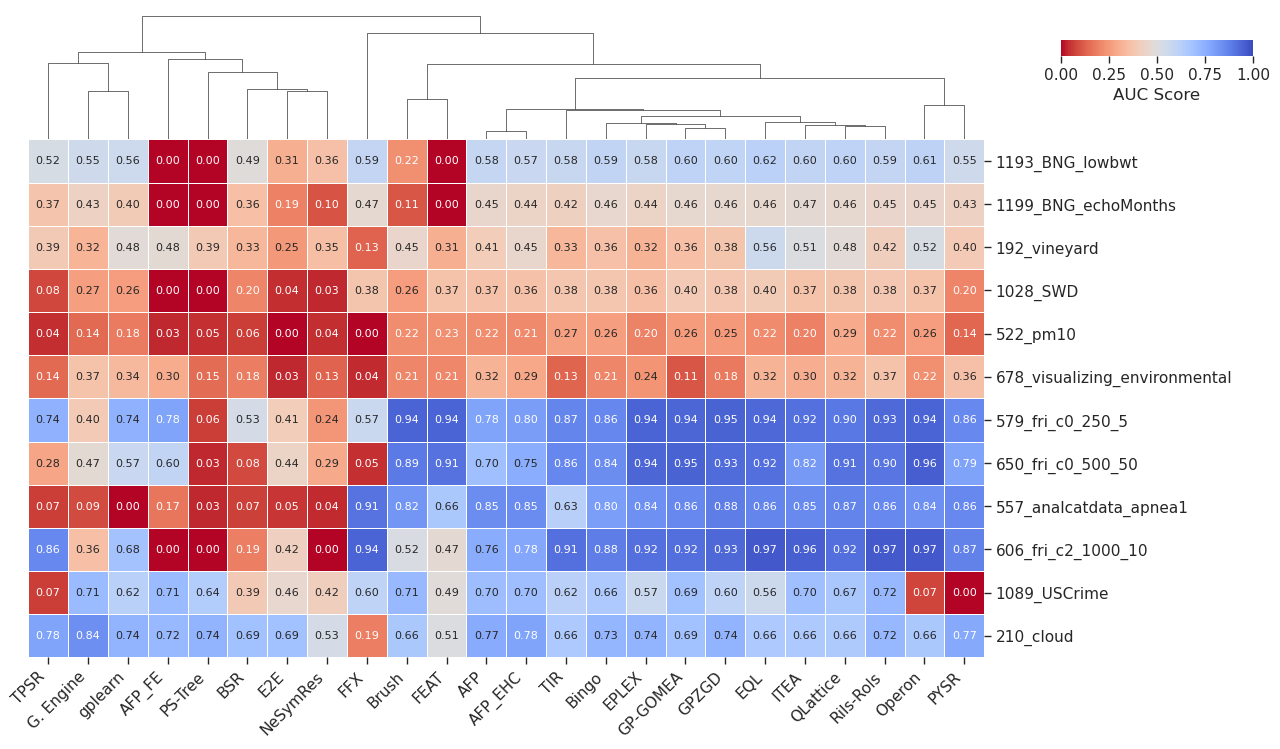

In [6]:
def perf_table(df, perf_measure, interval=(0.0, 1.0), errorbar=None):
    """
    Compute a performance summary table (AUC and model size) for each algorithm-dataset pair.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame containing ['algorithm', 'dataset', 'random_state', perf_measure, 'model_size'].
    perf_measure : str
        Name of the performance metric column (e.g., 'r2_test').
    interval : tuple of float, optional
        Unused here but kept for consistency with related plotting functions.
    errorbar : str or None, optional
        Placeholder parameter for compatibility (not used).

    Returns
    -------
    pandas.DataFrame
        Table containing per-algorithm, per-dataset statistics:
        ['algorithm', 'dataset', 'AUC', 'mean_model_size', 'valid'].
    """
    base_fpr = np.linspace(0, 1, 51)
    df = df[['algorithm', 'dataset', 'random_state', perf_measure, 'model_size']]
    n_problems = df['random_state'].nunique()
    data = []

    # Compute AUC and mean model size for each algorithm-dataset pair
    for (alg, ds), view in df.groupby(['algorithm', 'dataset']):
        view = view[view[perf_measure] >= 0].sort_values(by=perf_measure)
        n_gt0 = view.shape[0]

        if n_gt0==0: # ignoring groups with no results
            continue

        perf_x, perf_y = [0], [n_gt0 / n_problems]

        # Build performance curve
        for k, perf in Counter(view[perf_measure].values).items():
            if k == 0:
                n_gt0 -= perf
                continue
            perf_x.append(k)
            perf_y.append(n_gt0 / n_problems)
            n_gt0 -= perf

        # Interpolate and compute AUC
        perf_y = np.interp(base_fpr, perf_x, perf_y)
        AUC_val = auc(base_fpr, perf_y)
        mean_size = np.mean(view['model_size'].values)
        counts = (view['model_size'] > 0).sum()
        data.append((alg, ds, AUC_val, mean_size, counts))

    perf_table_df = pd.DataFrame(
        data=data,
        columns=['algorithm', 'dataset', 'AUC', 'mean_model_size', 'valid']
    )
    return perf_table_df


# === Generate and visualize the performance table ===
perf_table_df = perf_table(df_plot, "r2_test", errorbar=None).drop(columns=['mean_model_size'])
perf_table_pivot = perf_table_df.pivot(columns='algorithm', index='dataset', values='AUC').fillna(0.0)

# display(perf_table_pivot.style.background_gradient(axis=None, cmap='coolwarm_r'))

g_cluster = sns.clustermap(
    perf_table_pivot,
    annot=True,
    fmt='.2f',
    cmap='coolwarm_r',
    center=0.5,
    vmin=0,
    vmax=1,
    annot_kws={'size': 8},
    linewidths=0.5,
    square=False,
    cbar_pos=(.86, .92, .128, .019),
    # cbar_pos=(.82, .92, .148, .019),
    cbar_kws={'label': 'AUC Score', "orientation": "horizontal"},
    figsize=(15, 8)
)

g_cluster.ax_heatmap.set_ylabel("")
g_cluster.ax_heatmap.set_xlabel("")
g_cluster.ax_row_dendrogram.set_visible(False) 

plt.setp(g_cluster.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
save(name='r2_AUC_tuning', figdir=figdir, tight_layout=False)

# Sumarizing model sizes by keeping clusters from the previous heatmap

Filling missing values or bad sizes with median size 32.0
Saving ../figs/black-box-tuning/model_sizes.pdf


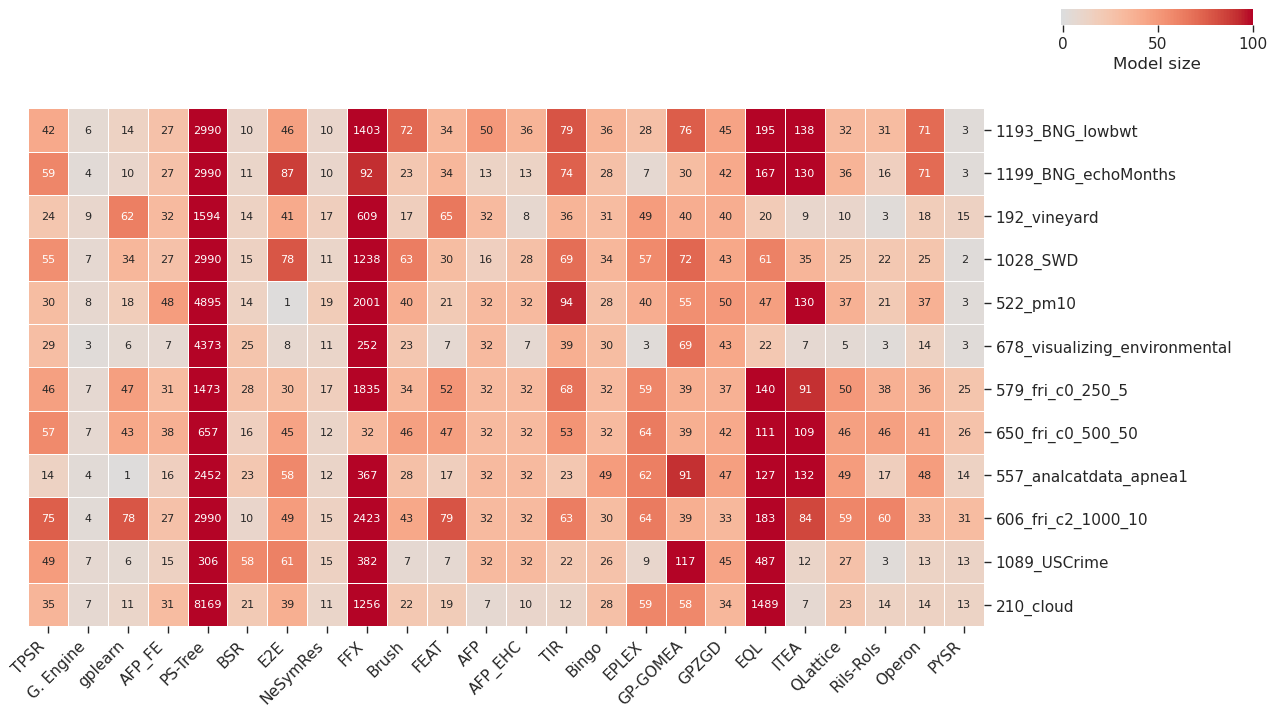

In [7]:
# === Size of the best expressions ===
df_plot_heatmap = df_plot.copy().dropna(subset=['r2_zero_test', 'model_size'])

# Replace or remove invalid sizes
med_size = np.nanmedian(df_plot_heatmap.loc[df_plot_heatmap['model_size'] > 0, 'model_size'])
print("Filling missing values or bad sizes with median size", med_size)
mask = df_plot_heatmap['model_size'] <= 0
df_plot_heatmap.loc[mask, 'model_size'] = med_size

# Select best performing r2 per (algorithm, dataset)
df_plot_heatmap = (
    df_plot_heatmap
    .sort_values(['algorithm', 'dataset', 'r2_zero_test', 'model_size'], ascending=[True, True, False, True])
    .drop_duplicates(subset=['algorithm', 'dataset'], keep='first')
    [['algorithm', 'dataset', 'model_size']]
)

# Pivot table
df_plot_heatmap = df_plot_heatmap.pivot(index='dataset', columns='algorithm', values='model_size')

# Fill missing algorithm results
df_plot_heatmap = df_plot_heatmap.fillna(df_plot_heatmap.mean())

# Reorder to match dendrogram
df_plot_heatmap = df_plot_heatmap.iloc[g_cluster.dendrogram_row.reordered_ind, :]
df_plot_heatmap = df_plot_heatmap.iloc[:, g_cluster.dendrogram_col.reordered_ind]

# Plot
g = sns.clustermap(
    df_plot_heatmap,
    annot=True,
    fmt='.0f',
    cmap='coolwarm',
    vmin=-1,
    center=0,
    vmax=100,
    annot_kws={'size': 8},
    linewidths=0.5,
    square=False,
    row_cluster=False,
    col_cluster=False,
    cbar_pos=(.86, .92, .128, .019),
    cbar_kws={'label': 'Model size', "orientation": "horizontal"},
    figsize=(15, 8)
)

# Final touches
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xlabel("")
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')

save(name='model_sizes', figdir=figdir, tight_layout=False)

# Plotting AUC and size together

Using cell size to represent average model sizes

Filling missing or invalid sizes with median size: 32.0
Saving ../figs/black-box-tuning/r2_AUC_tuning_with_sizes.pdf


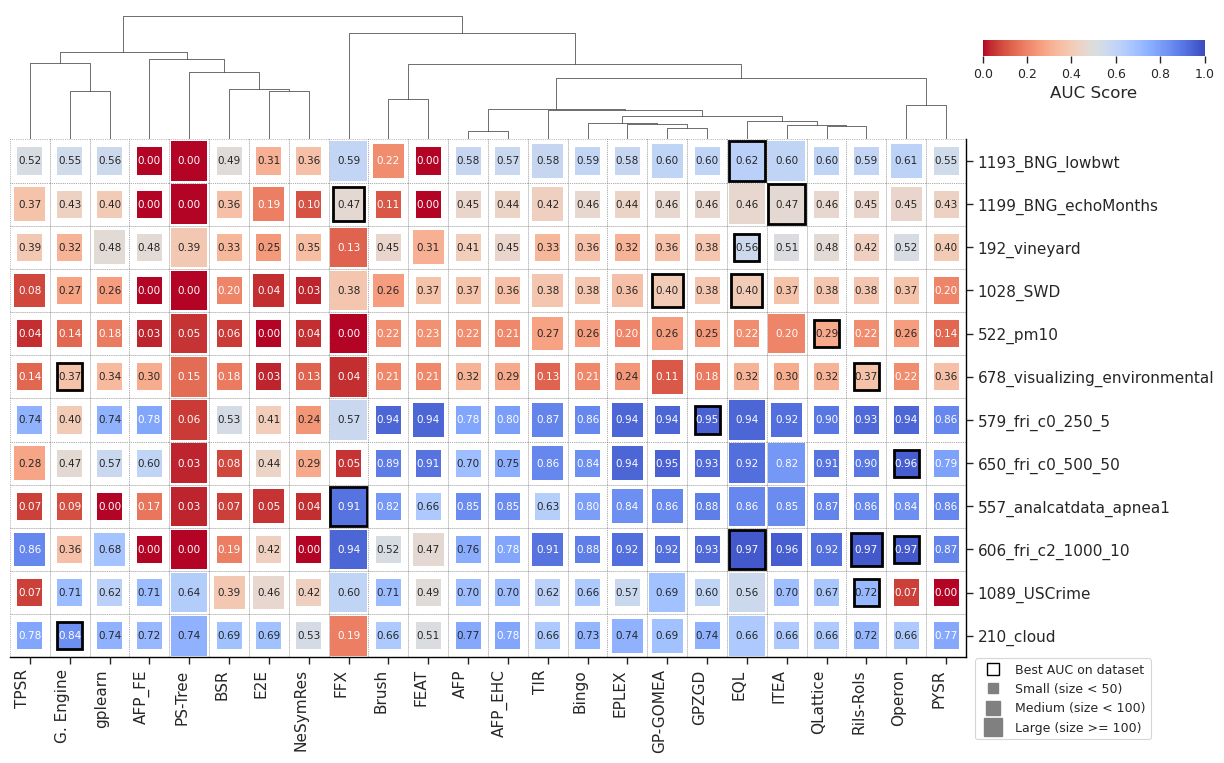

In [8]:
# === Combining both AUC and size ===
df_plot_aux = df_plot.copy()

# Replace invalid model sizes with median
valid_sizes = df_plot_aux.loc[df_plot_aux['model_size'] > 0, 'model_size']
med_size = np.nanmedian(valid_sizes) if not valid_sizes.empty else 50
print("Filling missing or invalid sizes with median size:", med_size)

mask = df_plot_aux['model_size'] <= 0
df_plot_aux.loc[mask, 'model_size'] = med_size

# Keep only valid
df_plot_aux = df_plot_aux[df_plot_aux['model_size'] > 0]

# Compute AUC performance table
perf_table_df = perf_table(df_plot_aux, "r2_test", errorbar=None)

# Number of valid runs (for transparency)
counts_table_pivot = perf_table_df.pivot(columns='algorithm', index='dataset', values='valid').fillna(0.0)
counts_table_pivot = counts_table_pivot.iloc[g_cluster.dendrogram_row.reordered_ind]

# Pivot AUC results
perf_table_pivot = perf_table_df.pivot(columns='algorithm', index='dataset', values='AUC').fillna(0.0)
perf_table_pivot = perf_table_pivot.iloc[g_cluster.dendrogram_row.reordered_ind, g_cluster.dendrogram_col.reordered_ind]

# Reuse same column order as previous clustering (important)
g_cluster2 = sns.clustermap(
    perf_table_pivot,
    annot=True,
    fmt='.2f',
    cmap='coolwarm_r',
    center=0.5,
    vmin=0,
    vmax=1,
    annot_kws={'size': 7.5},
    linewidths=0.5,
    square=False,
    row_cluster=False,
    cbar_pos=(.82, .92, .148, .019),
    cbar_kws={'label': 'AUC Score', "orientation": "horizontal"},
    figsize=(15, 8)
)

g_cluster2.ax_cbar.tick_params(labelsize=9)
g_cluster2.ax_heatmap.set_ylabel("")
g_cluster2.ax_heatmap.set_xlabel("")
g_cluster2.ax_row_dendrogram.set_visible(False)
plt.setp(g_cluster2.ax_heatmap.get_xticklabels(), rotation=90, ha='right')

# Identify best models
best_idxs = []
flat_index = 0
for i in range(perf_table_pivot.shape[0]):
    values = perf_table_pivot.iloc[i].round(2).values
    not_nan_values = values[~np.isnan(values)]
    if len(not_nan_values) == 0:
        continue
    best_idxs += [flat_index + j for j, val in enumerate(not_nan_values) if val == np.nanmax(not_nan_values)]
    flat_index += len(not_nan_values)

# Overlay model size boxes
texts_auc = g_cluster2.ax_heatmap.texts
texts_size = g.ax_heatmap.texts

for i, (t_auc, t_size) in enumerate(zip(texts_auc, texts_size)):
    if t_auc.get_text() == '' or t_size.get_text() == '':
        # No data: draw empty gray box
        g_cluster2.ax_heatmap.add_patch(Rectangle(
            [p - 0.5 for p in t_size.get_position()], 1, 1, fc='white', ec='gray', lw=0.5, ls=':'
        ))
        continue

    model_size = int(t_size.get_text())
    # Discrete mapping
    if model_size >= 100:
        rate = -0.05
    elif model_size > 50:
        rate = 0.4
    else:
        rate = 0.9
    totsize = 0.9 - rate * 0.3

    # Reconstruct color from colormap instead of facecolor index
    cmap = plt.get_cmap('coolwarm_r')
    auc_val = float(t_auc.get_text())
    c = cmap((auc_val - 0) / (1 - 0))

    # Border box (background)
    g_cluster2.ax_heatmap.add_patch(Rectangle(
        [p - 0.5 for p in t_size.get_position()], 1, 1, fc='white', ec='gray', lw=0.5, ls=':'
    ))

    # Main proportional box
    if i in best_idxs:
        g_cluster2.ax_heatmap.add_patch(Rectangle(
            [p - (totsize / 2) for p in t_size.get_position()],
            totsize, totsize, fc=c, ec='black', lw=2
        ))
    else:
        g_cluster2.ax_heatmap.add_patch(Rectangle(
            [p - (totsize / 2) for p in t_size.get_position()],
            totsize, totsize, fc=c, ec='none', lw=0
        ))

# Frame borders
for key, spine in g_cluster2.ax_heatmap.spines.items():
    if key not in ('left', 'top'):
        spine.set_visible(True)
        spine.set_edgecolor('black')

# Legend
patch_best = g_cluster2.ax_heatmap.plot([],[], marker='s', ms=8, lw=2, markeredgecolor='k', color='white', label='Best AUC on dataset')
patch_small = g_cluster2.ax_heatmap.plot([],[], marker='s', ms=7, ls="", color='gray', label='Small (size < 50)')
patch_medium = g_cluster2.ax_heatmap.plot([],[], marker='s', ms=10, ls="", color='gray', label='Medium (size < 100)')
patch_large = g_cluster2.ax_heatmap.plot([],[], marker='s', ms=13, ls="", color='gray', label='Large (size >= 100)')
g_cluster2.ax_heatmap.legend(handles=patch_best+patch_small+patch_medium+patch_large, bbox_to_anchor=(1.2, 0.01), fontsize=9)

save(name='r2_AUC_tuning_with_sizes', figdir=figdir, tight_layout=False)

# Performance plots for each dataset

Saving ../figs/black-box-tuning/r2_perf_intervals_1028_SWD.pdf
Saving ../figs/black-box-tuning/r2_perf_intervals_579_fri_c0_250_5.pdf


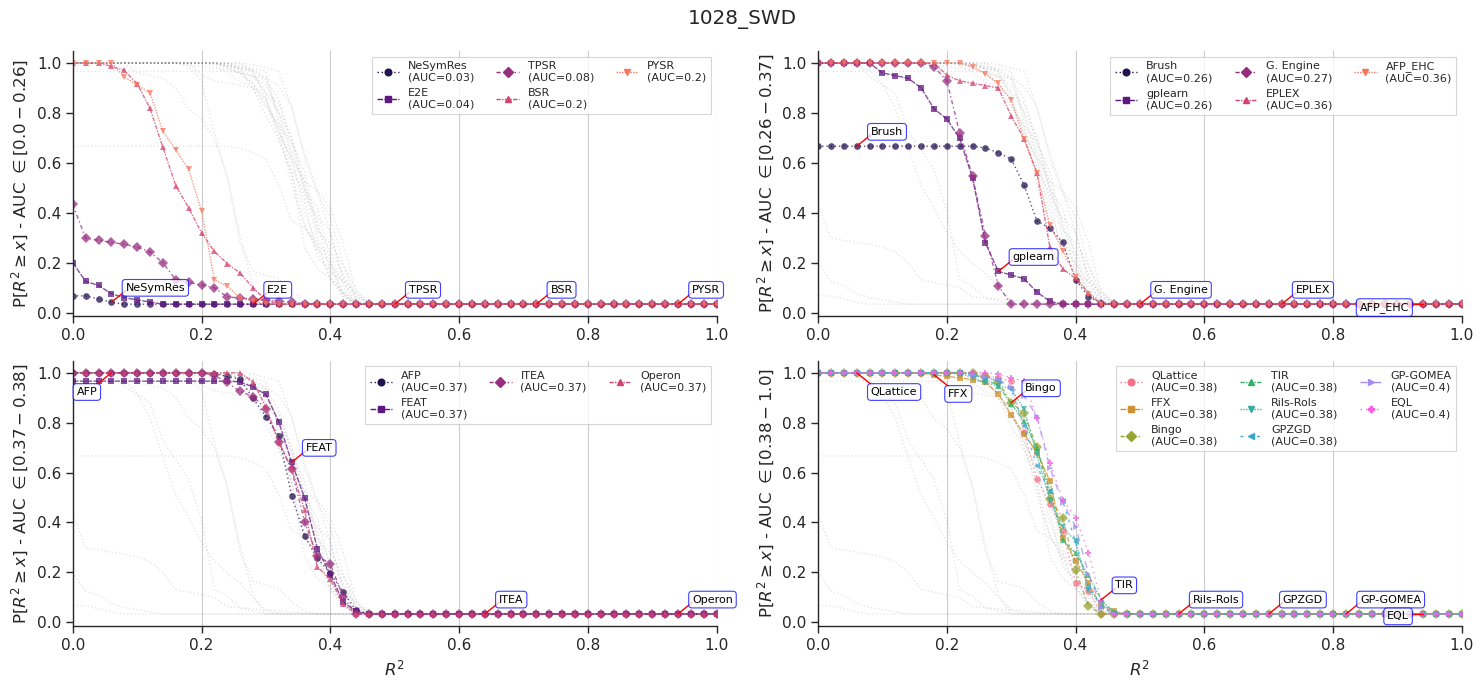

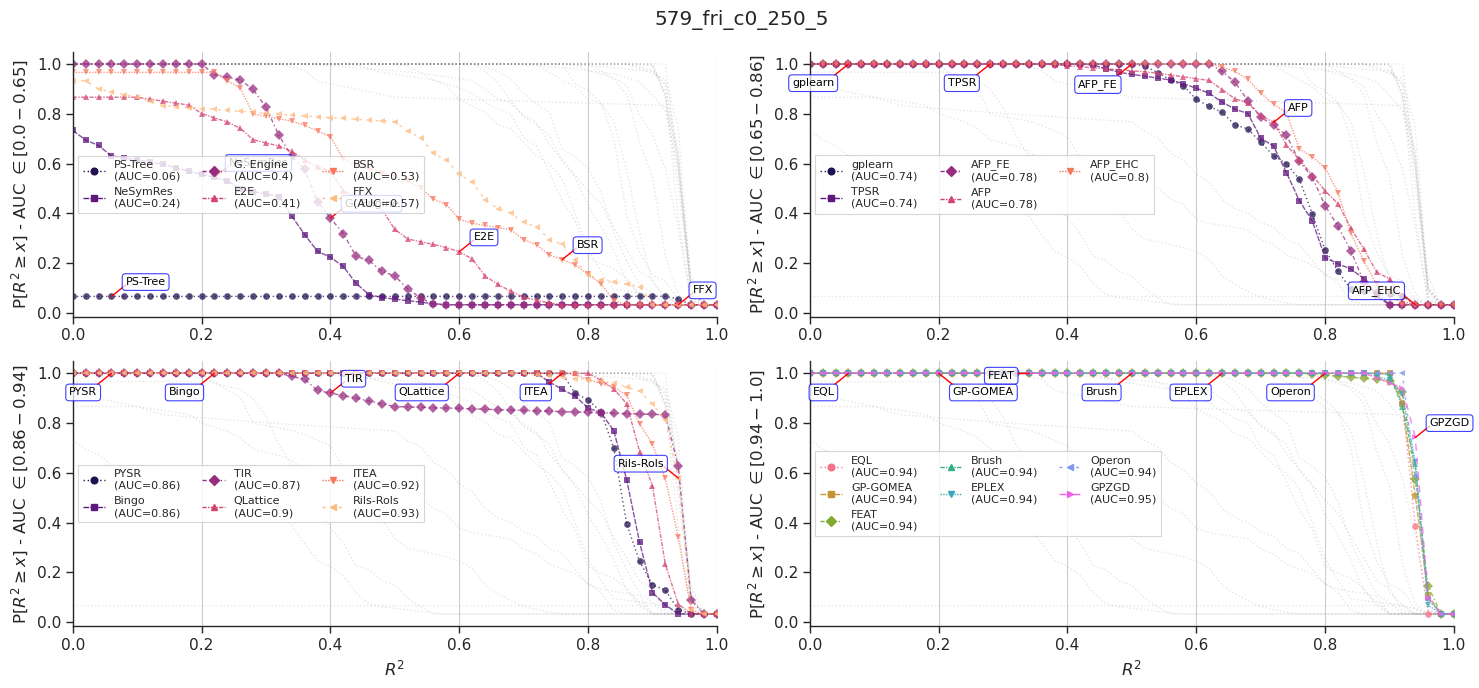

In [9]:
# Compute AUC per algorithm–dataset and reshape
perf_table_df = perf_table(df_plot, "r2_test", errorbar=None).drop(columns=['mean_model_size'])
perf_table_pivot = perf_table_df.pivot(columns='dataset', index='algorithm', values='AUC')

for ds in [
    '1028_SWD', 
    # '1089_USCrime', 
    # '1193_BNG_lowbwt', 
    # '1199_BNG_echoMonths', 
    # '192_vineyard', 
    # '210_cloud', 
    # '522_pm10', 
    # '557_analcatdata_apnea1', 
    '579_fri_c0_250_5', 
    # '606_fri_c2_1000_10',
    # '650_fri_c0_500_50',
    # '678_visualizing_environmental'
]:
    data = df_plot[df_plot['dataset'] == ds].copy()

    # Fake dataset labels to simulate different trials for profiling visualization
    data['dataset'] = data['random_state'].astype(str)
    data['random_state'] = 123

    if data.empty:
        continue

    fig, axs = plt.subplots(2, 2, figsize=(15, 7))

    # Determine quartile intervals of AUC for grouping algorithms by performance
    try:
        data_quartiles = perf_table_pivot[ds].dropna().values
        q1, q2, q3 = np.quantile(data_quartiles, [0.25, 0.5, 0.75], method='midpoint')
        intervals = [(0, q1), (q1, q2), (q2, q3), (q3, 1.0)]
    except Exception as e:
        warnings.warn(f"Failed to compute quartiles for dataset {ds}: {e}")
        traceback.print_exc()
        continue

    # Plot performance profiles for each quartile range
    for i, (ax, interval) in enumerate(zip(fig.axes, intervals)):
        perfprof_plot(
            data,
            "r2_test",
            interval=interval,
            errorbar='ci',
            estimator=np.mean,
            ax=ax,
            legend=True,
            legend_loc='best',
            xlabel=i > 1  # Only label x-axis on bottom row
        )

    fig.subplots_adjust(top=0.93)
    fig.suptitle(ds, y=0.98)
    save(name=f'r2_perf_intervals_{ds}', figdir=figdir)


# Table with training times

Saving ../figs/black-box-tuning/training_time.pdf


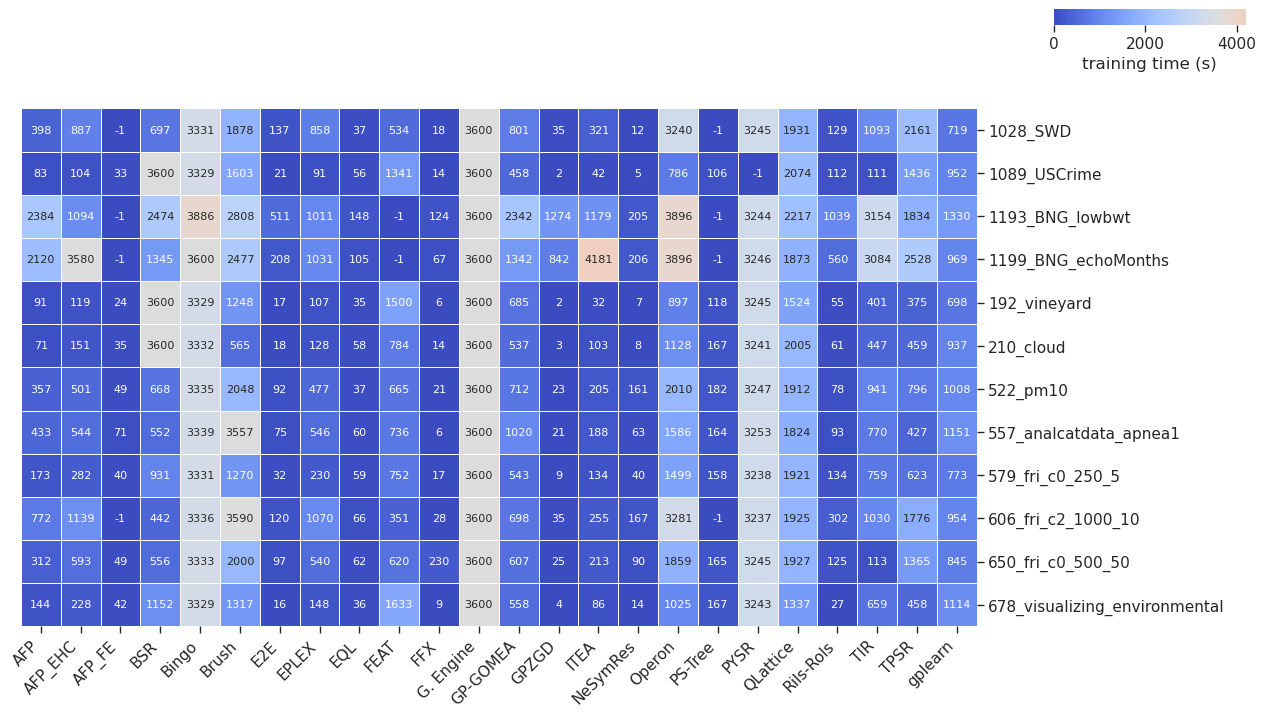

In [10]:
# Size of the best expressions
df_plot_heatmap = df_plot.copy().dropna(subset=['training time (s)'])

# Selecting as final result the best performing r2
idx = df_plot_heatmap.groupby(['algorithm', 'dataset'])['training time (s)'].transform(np.nanmax) == df_plot_heatmap['training time (s)']

# Eliminating duplicated r2 performances by picking the smaller model
df_plot_heatmap = df_plot_heatmap[idx].sort_values(['algorithm', 'dataset', 'training time (s)']).groupby(['algorithm', 'dataset']).head(1)[['algorithm', 'dataset', 'training time (s)']]

df_plot_heatmap = df_plot_heatmap.pivot(columns='algorithm', index='dataset', values='training time (s)').fillna(-1)

g = sns.clustermap(
    df_plot_heatmap,
    annot=True,
    fmt='.0f',
    cmap='coolwarm',
    annot_kws={'size': 8},
    linewidths=0.5,
    square=False,
    center=3600,
    row_cluster=False,
    col_cluster=False,
    cbar_pos=(.86, .92, .128, .019),
    # cbar_pos=(.82, .92, .148, .019),
    cbar_kws={'label': 'training time (s)', "orientation": "horizontal"},
    figsize=(15, 8)
)

g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xlabel("")
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
save(name='training_time', figdir=figdir, tight_layout=False)